# Otimizacao de Rotas Medicas com Algoritmo Genetico

Notebook ponta a ponta do desafio: carrega o catalogo de pontos, calcula distancias (Haversine), avalia cromossomos, roda o algoritmo genetico, visualiza a convergencia e a rota, compara com baselines nos experimentos E1/E2/E3 e gera um relatorio em linguagem natural.

As secoes 3 e 4 usam cromossomos fixos apenas para demonstrar a funcao `evaluate()`; a partir da secao 6 o algoritmo genetico encontra a rota de fato.

Configuracao inicial para importar os modulos do projeto.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Carrega variaveis do arquivo .env (ex.: GEMINI_API_KEY). O .env nao vai para o Git.
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env")
except ImportError:
    pass  # python-dotenv e opcional; sem ele, use variavel de ambiente do sistema

from src.config import DEFAULT_CONFIG
from src.data_loader import get_hospitals, get_origin, get_supply_stations, load_points
from src.distance import build_distance_matrix
from src.fitness import evaluate

## 1. Carregar catalogo de pontos

O catalogo contem a origem, os hospitais obrigatorios e os pontos de abastecimento.

In [2]:
points = load_points(PROJECT_ROOT / "data" / "pontos_entrega.csv")

origin = get_origin(points)
hospitals = get_hospitals(points)
supply_stations = get_supply_stations(points)

print(f"Origem: {origin.idx} - {origin.name}")
print(f"Hospitais: {len(hospitals)}")
print(f"Abastecimentos: {len(supply_stations)}")
print(f"Total de pontos: {len(points)}")

for point in points:
    print(f"{point.idx:>3} | {point.type:<8} | {point.name:<24} | prioridade={point.priority or '-':<5} | demanda={point.demand}")

Origem: 0 - Hospital Central - Brasilia
Hospitais: 25
Abastecimentos: 6
Total de pontos: 32
  0 | origin   | Hospital Central - Brasilia | prioridade=-     | demanda=0
  1 | hospital | Hospital Sao Paulo       | prioridade=ALTA  | demanda=40
  2 | hospital | Hospital Rio de Janeiro  | prioridade=ALTA  | demanda=35
  3 | hospital | Hospital Belo Horizonte  | prioridade=MEDIA | demanda=25
  4 | hospital | Hospital Salvador        | prioridade=ALTA  | demanda=30
  5 | hospital | Hospital Fortaleza       | prioridade=MEDIA | demanda=20
  6 | hospital | Hospital Recife          | prioridade=ALTA  | demanda=30
  7 | hospital | Hospital Porto Alegre    | prioridade=MEDIA | demanda=25
  8 | hospital | Hospital Curitiba        | prioridade=BAIXA | demanda=15
  9 | hospital | Hospital Manaus          | prioridade=ALTA  | demanda=35
 10 | hospital | Hospital Belem           | prioridade=MEDIA | demanda=20
 11 | hospital | Hospital Goiania         | prioridade=BAIXA | demanda=15
 12 | hospital | H

## 2. Calcular matriz de distancias

A matriz guarda a distancia entre cada par de pontos. Ela nao gera rotas nem testa combinacoes; apenas evita recalcular distancias.

In [3]:
distance_matrix = build_distance_matrix(points)

print(f"Pares calculados: {len(distance_matrix)}")
print(f"Exemplo 0 -> 1: {distance_matrix[(0, 1)]:.4f}")
print(f"Exemplo 1 -> 0: {distance_matrix[(1, 0)]:.4f}")

Pares calculados: 1024
Exemplo 0 -> 1: 872.3398
Exemplo 1 -> 0: 872.3398


## 3. Avaliar um cromossomo manual

Nesta etapa, o cromossomo e informado manualmente apenas para demonstrar a funcao de avaliacao. A capacidade inicial do veiculo vem de `DEFAULT_CONFIG.vehicle_capacity`.

In [4]:
chromosome = [3, 1, 5, 2, 4]

result = evaluate(chromosome, points, distance_matrix, DEFAULT_CONFIG)

print(f"Capacidade inicial do veiculo: {DEFAULT_CONFIG.vehicle_capacity}")
print(f"Peso da prioridade: {DEFAULT_CONFIG.lambda_priority}")
print(f"Peso do abastecimento: {DEFAULT_CONFIG.lambda_supply}")
print()
print(f"Cromossomo: {result.chromosome}")
print(f"Rota decodificada: {result.decoded_route}")
print(f"Distancia total: {result.total_distance:.4f}")
print(f"Penalidade de prioridade: {result.priority_penalty:.2f}")
print(f"Penalidade de abastecimento: {result.supply_penalty:.2f}")
print(f"Reabastecimentos: {result.resupply_count}")
print(f"Fitness: {result.fitness:.2f}")
print(f"Valido: {result.is_valid}")
print(f"Erros: {result.errors}")

Capacidade inicial do veiculo: 100
Peso da prioridade: 5.0
Peso do abastecimento: 10.0

Cromossomo: [3, 1, 5, 2, 4]
Rota decodificada: [0, 3, 1, 5, 101, 2, 4, 0]
Distancia total: 7944.0181
Penalidade de prioridade: 41.00
Penalidade de abastecimento: 1.00
Reabastecimentos: 1
Fitness: 8159.02
Valido: True
Erros: []


## 4. Exemplo com abastecimento

Neste exemplo, a capacidade do veiculo e 100. As demandas dos hospitais escolhidos sao 40, 35 e 30. Depois das duas primeiras entregas, restam 25 de carga; como o proximo hospital demanda 30, o decoder insere um abastecimento antes da entrega.

In [5]:
chromosome_with_resupply = [1, 2, 4]
result_with_resupply = evaluate(chromosome_with_resupply, points, distance_matrix, DEFAULT_CONFIG)

for hospital_idx in chromosome_with_resupply:
    hospital = next(point for point in points if point.idx == hospital_idx)
    print(f"Hospital {hospital.idx}: demanda={hospital.demand}")

print()
print(f"Carga inicial: {DEFAULT_CONFIG.vehicle_capacity}")
print(f"Cromossomo: {result_with_resupply.chromosome}")
print(f"Rota decodificada: {result_with_resupply.decoded_route}")
print(f"Reabastecimentos: {result_with_resupply.resupply_count}")
print(f"Penalidade de abastecimento: {result_with_resupply.supply_penalty:.2f}")
print(f"Fitness: {result_with_resupply.fitness:.2f}")

Hospital 1: demanda=40
Hospital 2: demanda=35
Hospital 4: demanda=30

Carga inicial: 100
Cromossomo: [1, 2, 4]
Rota decodificada: [0, 1, 2, 100, 4, 0]
Reabastecimentos: 1
Penalidade de abastecimento: 1.00
Fitness: 4318.31


## 5. Uso esperado

A funcao principal entregue e:

```python
result = evaluate(chromosome, points, distance_matrix, config)
```

Ela recebe um cromossomo pronto e devolve a rota decodificada, a distancia, as penalidades e a fitness.

## 6. Visualizacao da evolucao do algoritmo genetico

As celulas abaixo executam o algoritmo genetico completo e visualizam o resultado:

- a **curva de convergencia** da fitness (melhor e media por geracao);
- o **mapa da melhor rota** encontrada, com origem, hospitais (cor e tamanho por prioridade) e abastecimentos diferenciados.

Os graficos aparecem inline; nao e preciso salvar em arquivo dentro do notebook.

In [6]:
from dataclasses import replace

from src.genetic_algorithm import run_genetic_algorithm
from src.visualization import plot_fitness_evolution, plot_route_map

# reaproveita points e distance_matrix carregados nas secoes anteriores
config = replace(DEFAULT_CONFIG, seed=42)  # seed fixa deixa o resultado reproduzivel
evolution = run_genetic_algorithm(points, distance_matrix, config)
best = evolution.best

print(f"Geracoes: {evolution.generations}")
print(f"Melhor cromossomo: {best.chromosome}")
print(f"Melhor rota: {best.decoded_route}")
print(f"Distancia total: {best.total_distance:.2f} km")
print(f"Reabastecimentos: {best.resupply_count}")
print(f"Melhor fitness: {best.fitness:.2f}")

Geracoes: 200
Melhor cromossomo: [24, 23, 9, 25, 10, 13, 17, 5, 15, 18, 6, 14, 20, 4, 22, 3, 2, 1, 12, 8, 21, 7, 16, 19, 11]
Melhor rota: [0, 24, 23, 9, 102, 25, 10, 13, 17, 5, 101, 15, 18, 6, 14, 20, 105, 4, 22, 3, 100, 2, 1, 12, 100, 8, 21, 7, 16, 104, 19, 11, 0]
Distancia total: 17015.06 km
Reabastecimentos: 6
Melhor fitness: 20310.06


<Axes: title={'center': 'Evolucao da fitness por geracao'}, xlabel='Geracao', ylabel='Fitness (menor e melhor)'>

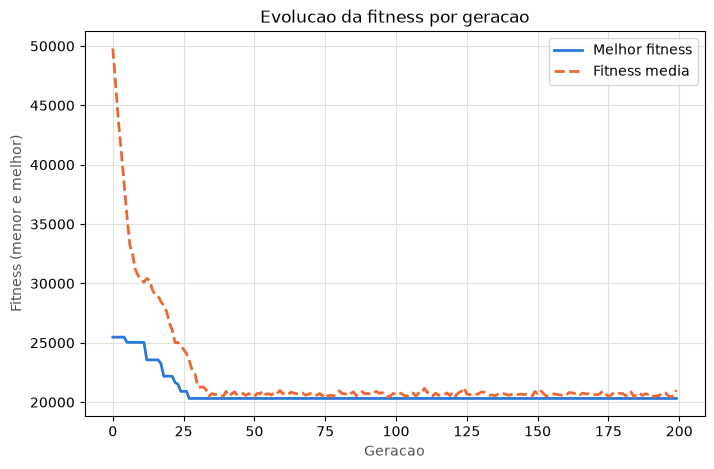

In [7]:
plot_fitness_evolution(evolution)

<Axes: title={'center': 'Rota final no mapa do Brasil (origem, hospitais por prioridade e abastecimentos)'}, xlabel='Longitude', ylabel='Latitude'>

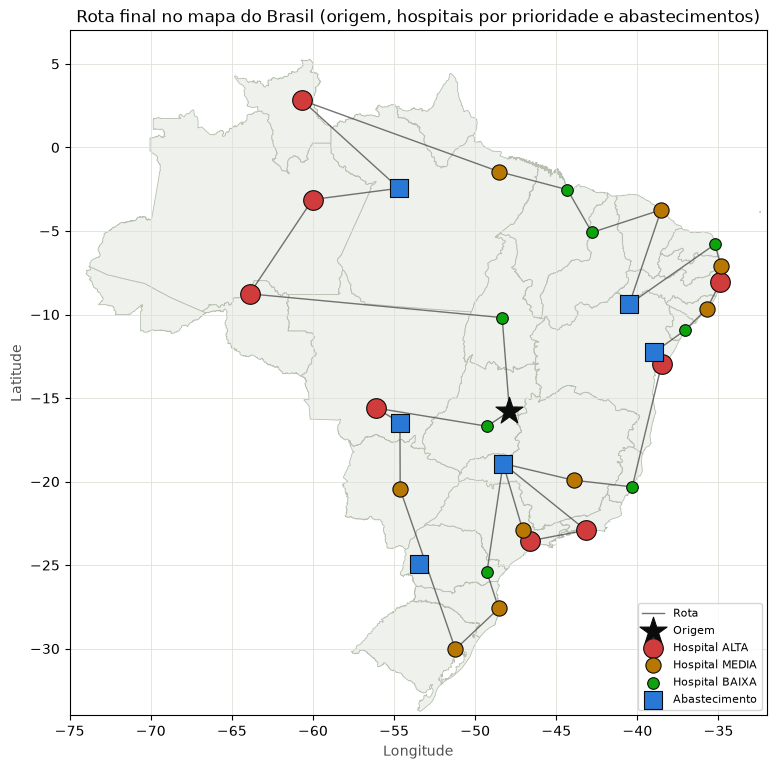

In [8]:
plot_route_map(points, best.decoded_route)

## 7. Experimentos e comparacao

Aqui rodamos os tres experimentos do plano — **E1** (50/100/5%), **E2** (100/200/10%) e **E3** (200/300/15%) — com seed fixa, comparando a rota aleatoria, o nearest neighbor e o algoritmo genetico.

Para cada metodo coletamos distancia, reabastecimentos, posicao media dos hospitais ALTA (`PosCrit`), fitness e tempo, alem do ganho percentual do GA sobre cada baseline.

In [9]:
from src.experiments import run_all_experiments, format_comparison_table

# roda E1, E2 e E3 com seed fixa e compara aleatoria x nearest neighbor x GA
experiment_results = run_all_experiments(points, distance_matrix, DEFAULT_CONFIG, seed=42)
print(format_comparison_table(experiment_results))

Exp Metodo                Dist(km)  Reab  PosCrit   Fitness  Tempo(s)
---------------------------------------------------------------------
E1 (pop=50, ger=100, mut=5%)
    Aleatoria             49825.55     6    16.12  53390.55     0.000
    Nearest neighbor      22028.27     6    16.00  25473.27     0.000
    Algoritmo genetico    19450.04     6    16.62  22855.04     0.286
    Ganho GA vs aleatoria:  57.2%  |  vs nearest neighbor:  10.3%

E2 (pop=100, ger=200, mut=10%)
    Aleatoria             49825.55     6    16.12  53390.55     0.000
    Nearest neighbor      22028.27     6    16.00  25473.27     0.000
    Algoritmo genetico    17015.06     6    11.62  20310.06     1.107
    Ganho GA vs aleatoria:  62.0%  |  vs nearest neighbor:  20.3%

E3 (pop=200, ger=300, mut=15%)
    Aleatoria             49825.55     6    16.12  53390.55     0.000
    Nearest neighbor      22028.27     6    16.00  25473.27     0.001
    Algoritmo genetico    17358.61     6    11.00  20603.61     3.474
    G

## 8. Relatorio em linguagem natural

A ultima etapa transforma o resultado do algoritmo em um relatorio para gestores. O payload serializado da melhor rota alimenta duas opcoes de geracao:

- um **template deterministico**, que sempre funciona (offline, sem chave de API);
- uma **LLM**, opcional, que explica o mesmo payload em linguagem natural (por padrao o **Google Gemini**, free tier).

Em ambos os casos a LLM apenas *explica* a rota ja calculada pelo algoritmo genetico; ela nao decide nem altera a rota.

In [10]:
from src.llm_report import build_route_payload, generate_report

# reaproveita 'best' (melhor individuo do GA) e 'points' das secoes anteriores
payload = build_route_payload(best, points, DEFAULT_CONFIG)

# Relatorio deterministico: sempre funciona, sem depender de rede ou chave
print(generate_report(payload))

RELATORIO DA ROTA DE DISTRIBUICAO MEDICA

Capacidade do veiculo: 100
Distancia total: 17015.06 km
Reabastecimentos: 6
Fitness final: 20310.06
Rota valida.

Hospitais de prioridade ALTA atendidos: Hospital Porto Velho (posicao 2), Hospital Manaus (posicao 3), Hospital Boa Vista (posicao 4), Hospital Recife (posicao 11), Hospital Salvador (posicao 14), Hospital Rio de Janeiro (posicao 17), Hospital Sao Paulo (posicao 18), Hospital Cuiaba (posicao 24).
Paradas de reabastecimento: Abastecimento Santarem, Abastecimento Petrolina, Abastecimento Feira de Santana, Abastecimento Uberlandia, Abastecimento Uberlandia, Abastecimento Rondonopolis.

Sequencia de visita:
Hospital Central - Brasilia -> Hospital Palmas -> Hospital Porto Velho -> Hospital Manaus -> Abastecimento Santarem -> Hospital Boa Vista -> Hospital Belem -> Hospital Sao Luis -> Hospital Teresina -> Hospital Fortaleza -> Abastecimento Petrolina -> Hospital Natal -> Hospital Joao Pessoa -> Hospital Recife -> Hospital Maceio -> Hospi

### Relatorio via LLM (opcional)

Usa o **Google Gemini** (free tier). Requer `pip install google-genai` e a variavel de ambiente `GEMINI_API_KEY` (crie a chave em https://aistudio.google.com). Sem a chave, a celula abaixo apenas avisa e o relatorio deterministico acima continua valendo.

In [11]:
import os

# Requer: pip install google-genai e a variavel de ambiente GEMINI_API_KEY.
# A LLM apenas explica a rota ja calculada (nao decide nem altera a rota).
if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
    try:
        print(generate_report(payload, use_llm=True))  # provider padrao: gemini
    except Exception as erro:
        print(f"Falha ao chamar a LLM: {erro}")
        print("\nMantendo o relatorio deterministico exibido acima.")
else:
    print("GEMINI_API_KEY nao definida - pulei a chamada a LLM.")
    print("Defina a chave e rode novamente esta celula para gerar o relatorio via Gemini.")

Aqui está o relatório da rota de distribuição médica:

**1. Resumo da rota e distância total em km:**
A rota de distribuição médica, partindo do Hospital Central - Brasília, seguirá para Hospital Palmas, Hospital Porto Velho, Hospital Manaus, Abastecimento Santarem, Hospital Boa Vista, Hospital Belem, Hospital Sao Luis, Hospital Teresina, Hospital Fortaleza, Abastecimento Petrolina, Hospital Natal, Hospital Joao Pessoa, Hospital Recife, Hospital Maceio, Hospital Aracaju, Abastecimento Feira de Santana, Hospital Salvador, Hospital Vitoria, Hospital Belo Horizonte, Abastecimento Uberlandia, Hospital Rio de Janeiro, Hospital Sao Paulo, Hospital Campinas, Abastecimento Uberlandia, Hospital Curitiba, Hospital Florianopolis, Hospital Porto Alegre, Hospital Campo Grande, Abastecimento Rondonopolis, Hospital Cuiaba, Hospital Goiania, e retornará ao Hospital Central - Brasília. A distância total percorrida é de 17015.06 km.

**2. Como os hospitais de prioridade ALTA foram atendidos:**
Os hospit

## 9. Outras aplicacoes da LLM

Alem do relatorio, a mesma integracao (item 3 do desafio) cobre:

1. **instrucoes para o motorista** e a equipe de entrega;
2. **perguntas em linguagem natural** sobre a rota (Q&A);
3. **relatorio de eficiencia** comparando os metodos (economia de tempo e recursos);
4. **sugestoes de melhoria** no processo.

Todas usam o Gemini quando `GEMINI_API_KEY` esta definida, com o mesmo controle de alucinacao (usam apenas os dados; nao decidem nem alteram a rota).

In [12]:
import os
from src.llm_report import generate_driver_instructions

# 1) Instrucoes passo a passo para o motorista e a equipe de entrega
if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
    print(generate_driver_instructions(payload))
else:
    print("Defina GEMINI_API_KEY para gerar as instrucoes do motorista.")

Aqui estão as instruções passo a passo para o motorista e a equipe de entrega seguirem a rota calculada:

1.  Partida do **Hospital Central - Brasilia**.
2.  Entregar no **Hospital Palmas**: Prioridade BAIXA, Demanda 10.
3.  Entregar no **Hospital Porto Velho**: Prioridade ALTA, Demanda 30.
4.  Entregar no **Hospital Manaus**: Prioridade ALTA, Demanda 35.
5.  **Reabastecer** no **Abastecimento Santarem**.
6.  Entregar no **Hospital Boa Vista**: Prioridade ALTA, Demanda 35.
7.  Entregar no **Hospital Belem**: Prioridade MEDIA, Demanda 20.
8.  Entregar no **Hospital Sao Luis**: Prioridade BAIXA, Demanda 15.
9.  Entregar no **Hospital Teresina**: Prioridade BAIXA, Demanda 10.
10. Entregar no **Hospital Fortaleza**: Prioridade MEDIA, Demanda 20.
11. **Reabastecer** no **Abastecimento Petrolina**.
12. Entregar no **Hospital Natal**: Prioridade BAIXA, Demanda 15.
13. Entregar no **Hospital Joao Pessoa**: Prioridade MEDIA, Demanda 20.
14. Entregar no **Hospital Recife**: Prioridade ALTA, Dema

In [13]:
import os
from src.llm_report import answer_question

# 2) Perguntas em linguagem natural sobre a rota (Q&A)
perguntas = [
    "Quantos reabastecimentos a rota faz e em quais pontos?",
    "Quantos hospitais de prioridade ALTA existem e em que posicoes sao atendidos?",
]
if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
    for pergunta in perguntas:
        print(f"P: {pergunta}")
        print(f"R: {answer_question(payload, pergunta)}\n")
else:
    print("Defina GEMINI_API_KEY para fazer perguntas em linguagem natural.")

P: Quantos reabastecimentos a rota faz e em quais pontos?


R: A rota faz 6 reabastecimentos. Os pontos de reabastecimento são: Abastecimento Santarem, Abastecimento Petrolina, Abastecimento Feira de Santana, Abastecimento Uberlandia e Abastecimento Rondonopolis.

P: Quantos hospitais de prioridade ALTA existem e em que posicoes sao atendidos?


R: Existem 8 hospitais de prioridade ALTA, que são atendidos nas seguintes posições:

*   Hospital Porto Velho: posição 2
*   Hospital Manaus: posição 3
*   Hospital Boa Vista: posição 4
*   Hospital Recife: posição 11
*   Hospital Salvador: posição 14
*   Hospital Rio de Janeiro: posição 17
*   Hospital São Paulo: posição 18
*   Hospital Cuiabá: posição 24



In [14]:
import os
from src.llm_report import build_efficiency_payload, generate_efficiency_report

# 3) Relatorio de eficiencia (usa os experimentos E1/E2/E3 da secao 7)
if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
    efficiency = build_efficiency_payload(experiment_results)
    print(generate_efficiency_report(efficiency))
else:
    print("Defina GEMINI_API_KEY para gerar o relatorio de eficiencia.")

Segue o relatório de eficiência das rotas:

**Relatório de Eficiência das Rotas**

Este relatório compara a eficiência das rotas de distribuição médica calculadas por três métodos: aleatória, nearest neighbor e algoritmo genético, ao longo de três experimentos (E1, E2, E3). A análise foca na economia de distância, nos ganhos percentuais do algoritmo genético sobre as baselines e no atendimento das prioridades.

---

**1. Desempenho por Experimento:**

*   **Experimento E1 (pop_size: 50, generations: 100, mutation_rate: 0.05)**
    *   **Distância da rota:**
        *   Aleatória: 49825.55 km
        *   Nearest Neighbor: 22028.27 km
        *   Algoritmo Genético: 19450.04 km
    *   **Ganhos do Algoritmo Genético:**
        *   Ganho vs. Aleatória: 57.2%
        *   Ganho vs. Nearest Neighbor: 10.3%
    *   **Detalhes da Rota Genética:**
        *   Reabastecimentos: 6
        *   Posição Média Prioridade Alta: 16.62
        *   Tempo de Execução: 0.286 s

*   **Experimento E2 (pop_si

In [15]:
import os
from src.llm_report import suggest_improvements

# 4) Sugestoes de melhoria no processo
if os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY"):
    print(suggest_improvements(payload))
else:
    print("Defina GEMINI_API_KEY para gerar as sugestoes de melhoria.")

Aqui estão algumas sugestões de melhoria baseadas nos dados fornecidos:

1.  **Priorizar Hospitais de Alta Prioridade mais cedo:** A penalidade de prioridade é de 647.0, um valor significativo. Hospitais como o Hospital Rio de Janeiro (prioridade ALTA, visit_position 17), Hospital São Paulo (prioridade ALTA, visit_position 18) e Hospital Cuiabá (prioridade ALTA, visit_position 24) são visitados muito tarde na rota. Reorganizar a sequência de visitas para atender esses hospitais de alta prioridade em posições mais iniciais poderia reduzir consideravelmente essa penalidade.

2.  **Revisar a Capacidade do Veículo para Reduzir Reabastecimentos:** A rota inclui 6 reabastecimentos. Em duas seções da rota (Santarem para Petrolina e Petrolina para Feira de Santana), a demanda total dos hospitais atendidos é de exatos 100, que é a capacidade máxima do veículo. Em outra seção (Uberlandia para Uberlandia), a demanda é de 95. Um ligeiro aumento na capacidade do veículo (atualmente 100) poderia per